# UGSC Multilingual Sentiment Dataset — Exploratory Analysis

**Dataset**: User Gold Standard Corpus (UGSC) — Multilingual Version  
**Study**: *Cross-Lingual Sentiment Classification in Sustainable Mobility: A Zero-Shot Evaluation Framework*  
**Citation**: Serna, A. (2024)

This notebook explores the dataset structure, translation coverage, sentiment classification results produced by a zero-shot **XLM-RoBERTa** model across five languages: English, Spanish, French, German, and Italian.

---

## 1. Import Libraries and Setup

In [17]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", 20)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.float_format", "{:.4f}".format)

# ── Paths ──────────────────────────────────────────────────────────────────────
BASE_DIR = r"c:\Users\Nguyen Ngo\Downloads\Thesis Quynh\UGSC_multilingual_sentiment_package\UGSC_multilingual_sentiment_package"

TRANSLATION_DIR   = os.path.join(BASE_DIR, "translated_versions")
PREDICTIONS_FILE  = os.path.join(BASE_DIR, "sentiment_predictions", "sentiment_classification_results.csv")

BLOCK_FILES = sorted(glob.glob(os.path.join(TRANSLATION_DIR, "block_*.csv")))

LANGUAGES = ["English", "Spanish", "French", "German", "Italian"]
LANG_COLORS = {
    "English":  "#4C72B0",
    "Spanish":  "#DD8452",
    "French":   "#55A868",
    "German":   "#C44E52",
    "Italian":  "#8172B2",
}
SENT_COLORS = {"positive": "#2ca02c", "neutral": "#ff7f0e", "negative": "#d62728"}

print("Libraries loaded successfully.")
print(f"Found {len(BLOCK_FILES)} translation block files:")
for f in BLOCK_FILES:
    print(" ", os.path.basename(f))

Libraries loaded successfully.
Found 4 translation block files:
  block_1_translation_template.csv
  block_2_translation_template.csv
  block_3_translation_template.csv
  block_4_translation_template.csv


## 2. Load and Preview Raw Translation Data

Each block CSV has columns: `English, Spanish, French, German, Italian` plus trailing delimiter columns.  
We preview the first few rows of every block.

In [18]:
raw_blocks = {}

for path in BLOCK_FILES:
    name = os.path.splitext(os.path.basename(path))[0] # e.g. "block_1_translation_template"
    df = pd.read_csv(path, encoding="latin-1", on_bad_lines="skip", engine="python")
    # Keep only the five language columns (first five)
    df = df.iloc[:, :5]
    df.columns = LANGUAGES
    raw_blocks[name] = df
    print(f"─── {name} ─── shape: {df.shape}")
    display(df.head(4))

─── block_1_translation_template ─── shape: (6, 5)


,,,,English,Spanish,French,German,Italian
Cable car gives quick access to spectacular views over Dubrovnik and out to the islands .,NaN,NaN,NaN,;El telefrico ofrece acceso rpido a vistas espectaculares de Dubrovnik y las islas.;Le tlph...,NaN,NaN,NaN,NaN
A museum at the top in an old fort and also good restaurant .,NaN,NaN,NaN,;Un museo en la cima de un antiguo fuerte y tambin un buen restaurante.;Un muse au sommet d'un...,NaN,NaN,NaN,NaN
A very short and expensive trip .,NaN,NaN,NaN,;Un viaje muy corto y caro.;Un trajet trs court et cher.;Eine sehr kurze und teure Fahrt.;Un vi...,NaN,NaN,NaN,NaN
Do not waste your money on the cable car .,NaN,NaN,NaN,;No malgastes tu dinero en el telefrico.;Ne gaspillez pas votre argent dans le tlphrique.;Ve...,NaN,NaN,NaN,NaN


─── block_2_translation_template ─── shape: (17, 5)


,English,Spanish,French,German,Italian
0,Dune buggies were available for driving !,NaN,NaN,NaN,;;Des buggys taient disponibles pour la conduiteÊ!;Dnenbuggys standen zum Fahren bereit!;Dune ...
1,Check out the cafe / restaurant and enjoy a drink whilst taking in the view !,NaN,NaN,NaN,;;Dcouvrez le caf/restaurant et prenez un verre tout en admirant la vueÊ!;Schaut euch das Caf...
2,Dubrovnik is a beautiful city to walk and explore .,NaN,NaN,NaN,;;Dubrovnik est une ville magnifique  explorer et  se promener.;Dubrovnik ist eine wunderschn...
3,Absolutely unacceptable .,NaN,NaN,NaN,;;Absolument inacceptable.;Absolut inakzeptabel.;Assolutamente inaccettabile.


─── block_3_translation_template ─── shape: (8, 5)


,,,,,,,,,,English,Spanish,French,German,Italian
excellent thing to do to pass the time and get good views of the city .,,,,;Una excelente opcin para pasar el rato y disfrutar de buenas vistas de la ciudad.;Excellente activit pour passer le temps et profiter d'une belle vue sur la ville.;Eine hervorragende Mglichkeit,sich die Zeit zu vertreiben und einen schnen Blick auf die Stadt zu genie§en.;cosa eccellente da fare per passare il tempo e avere una bella vista della citt .,,,,,,,,,
Bizarre and greedy,better get a taxi up there for your money .,NaN,NaN,NaN,;Es extrao y avaricioso,mejor coge un taxi para subir.;Bizarre et gourmand,mieux vaut prendre un taxi pour y aller.;Skurril und gierig,man sollte sich lieber ein Taxi nehmen,um sein Geld zu verdienen.;Bizzarro e avido,meglio prendere un taxi per i tuoi soldi .,NaN,NaN,NaN,NaN
But the best part is just next to it .,NaN,NaN,NaN,;Pero lo mejor est justo al lado.;Mais le meilleur est juste  ct.;Aber das Beste ist gleich daneben.;Ma la parte migliore  proprio l accanto .,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN
As everything else in Dubrovnik the cable car is crazy expensive ( and I live in Paris â°ÃÃ used to very high prices ) .,NaN,NaN,NaN,;Como todo en Dubrovnik,el telefrico es carsimo (y vivo en Pars,acostumbrado a precios muy altos).;Comme tout  Dubrovnik,le tlphrique est extrmement cher (et je vis  Paris,habitu aux prix trs levs).;Wie alles andere in Dubrovnik ist auch die Seilbahn wahnsinnig teuer (und ich lebe in Paris Ð bin an sehr hohe Preise gewhnt).;Come tutto il resto a Dubrovnik la funivia  follemente costosa (e io vivo a Parigi â°ÃÃ abituato a prezzi molto alti) .,NaN,NaN,NaN,NaN,NaN,NaN
At the top the panoramic views of this beautiful city are breathtaking .,NaN,NaN,NaN,;En la cima,las vistas panormicas de esta hermosa ciudad son impresionantes.;Du sommet,la vue panoramique sur cette magnifique ville est  couper le souffle.;Oben angekommen,ist der Panoramablick auf diese wunderschne Stadt atemberaubend.;In cima le viste panoramiche di questa bellissima citt sono mozzafiato .,NaN,NaN,NaN,NaN,NaN,NaN,NaN


─── block_4_translation_template ─── shape: (17, 5)


,,,,,,,,English,Spanish,French,German,Italian
Do this trip .,NaN,NaN,NaN,;Haz este viaje...;Faites ce voyageÉ;Machen Sie diesen Ausflug.,NaN,NaN,NaN,;Fai questo viaggio .,NaN,NaN,NaN,NaN
Absolutely beautiful .,NaN,NaN,NaN,;Absolutamente hermoso.;Absolument magnifiqueÉ;Einfach wunderschn.;Assolutamente meraviglioso.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Extremely expensive taxi with poor service quality .,NaN,NaN,NaN,;Taxi extremadamente caro con mala calidad de servicio.;Taxi extrmement cher avec un service mdiocreÉ;Extrem teures Taxi mit schlechtem Service.;Taxi estremamente costoso con scarsa qualit del servizio.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Each car hold 30 passengers so queueing time is not too long .,NaN,NaN,NaN,;Cada vagn tiene capacidad para 30 pasajeros,as que el tiempo de cola no es demasiado largo.;Chaque cabine peut accueillir 30 passagers,donc la file d'attente n'est pas trop longueÉ;Jede Kabine fasst 30 Passagiere,daher ist die Wartezeit nicht zu lang.;Ogni carrozza contiene 30 passeggeri quindi il tempo di attesa non  troppo lungo.,NaN,NaN,NaN,NaN,NaN


## 3. Merge and Clean All Translation Blocks

Combine the four blocks, strip trailing comma/whitespace artifacts (`,,,, `), and drop empty English rows.

In [19]:
import re

def clean_text(val):
    """Remove trailing commas/semicolons/whitespace artifacts."""
    if pd.isna(val):
        return np.nan
    val = str(val).strip()
    # Remove common trailing artifacts like ".,,,," or " .,,,,;"
    val = re.sub(r"[;,]+\s*$", "", val).strip()
    val = re.sub(r"\s*,{2,}\s*$", "", val).strip()
    return val if val else np.nan

# Concatenate all blocks
trans_df = pd.concat(raw_blocks.values(), ignore_index=True)

# Apply cleaning to all language columns
for lang in LANGUAGES:
    trans_df[lang] = trans_df[lang].apply(clean_text)

# Drop rows where English is empty (header rows re-appearing after concat, etc.)
trans_df = trans_df[trans_df["English"].notna()].reset_index(drop=True)

# Remove duplicate English sentences
before = len(trans_df)
trans_df = trans_df.drop_duplicates(subset="English").reset_index(drop=True)
after  = len(trans_df)

print(f"Total rows after merge      : {before}")
print(f"Total rows after dedup      : {after}  (removed {before - after} duplicates)")
print(f"\nFinal dataset shape: {trans_df.shape}")
trans_df.head(5)

Total rows after merge      : 29
Total rows after dedup      : 29  (removed 0 duplicates)

Final dataset shape: (29, 5)


,English,Spanish,French,German,Italian
0,;El telefrico ofrece acceso rpido a vistas espectaculares de Dubrovnik y las islas.;Le tlph...,NaN,NaN,NaN,NaN
1,;Un museo en la cima de un antiguo fuerte y tambin un buen restaurante.;Un muse au sommet d'un...,NaN,NaN,NaN,NaN
2,;Un viaje muy corto y caro.;Un trajet trs court et cher.;Eine sehr kurze und teure Fahrt.;Un vi...,NaN,NaN,NaN,NaN
3,;No malgastes tu dinero en el telefrico.;Ne gaspillez pas votre argent dans le tlphrique.;Ve...,NaN,NaN,NaN,NaN
4,;Definitivamente no te lo puedes perder.;Ë ne surtout pas manquer.;Auf keinen Fall verpassen.;Si...,NaN,NaN,NaN,NaN


## 4. Load Sentiment Classification Results

The file `sentiment_classification_results.csv` contains XLM-RoBERTa zero-shot predictions for all five language variants.

In [20]:
preds = pd.read_csv(PREDICTIONS_FILE, encoding="latin-1")
preds.columns = ["Language", "Text", "Sentiment", "Confidence"]

# Normalize language names
preds["Language"] = preds["Language"].str.strip()
preds["Sentiment"] = preds["Sentiment"].str.strip().str.lower()

# Drop rows without text (empty Spanish rows embedded in results)
preds = preds[preds["Text"].notna() & (preds["Text"].str.strip() != "")].reset_index(drop=True)

print("Columns:", preds.columns.tolist())
print("\nData types:\n", preds.dtypes)
print(f"\nTotal records   : {len(preds)}")
print("\nRecords per language:")
display(preds["Language"].value_counts().rename("count").to_frame())
preds.head(6)

Columns: ['Language', 'Text', 'Sentiment', 'Confidence']

Data types:
 Language       object
Text           object
Sentiment      object
Confidence    float64
dtype: object

Total records   : 933

Records per language:


,count
Language,
English,200
French,200
German,200
Italian,200
Spanish,133


,Language,Text,Sentiment,Confidence
0,English,"Cable car gives quick access to spectacular views over Dubrovnik and out to the islands .,,,,",positive,0.7234
1,English,"A museum at the top in an old fort and also good restaurant .,,,,",positive,0.6834
2,English,"Dubrovnik Old Town is magical and nowhere more so than at the top of the mountain , accessed by ...",positive,0.6594
3,English,"Even more disgruntled that we did not even get an apology from the company !,,,,",negative,0.9428
4,English,"A very short and expensive trip .,,,,",negative,0.6494
5,English,"Do not waste your money on the cable car .,,,,",negative,0.5966


## 5. Dataset Overview and Basic Statistics

In [21]:
eng_preds = preds[preds["Language"] == "English"]

print("=" * 55)
print(f"  Unique English sentences (translations):  {len(trans_df)}")
print(f"  Number of language variants              :  {len(LANGUAGES)}")
print(f"  Total classification records             :  {len(preds)}")
print(f"  Sentiment classes                        :  {sorted(preds['Sentiment'].unique())}")
print("=" * 55)

print("\n── Confidence score statistics (all languages) ──")
display(preds["Confidence"].describe().rename("Confidence").to_frame())

print("\n── Overall sentiment value counts ──")
display(preds["Sentiment"].value_counts().rename("count").to_frame())

  Unique English sentences (translations):  29
  Number of language variants              :  5
  Total classification records             :  933
  Sentiment classes                        :  ['negative', 'neutral', 'positive']

── Confidence score statistics (all languages) ──


,Confidence
count,933.0000
mean,0.7331
std,0.1631
min,0.3520
25%,0.6031
50%,0.7702
75%,0.8766
max,0.9690



── Overall sentiment value counts ──


,count
Sentiment,
positive,412
negative,366
neutral,155


## 6. Language Coverage Analysis

How complete are the translations? We count non-null, non-empty entries per language column.

Translation coverage per language:


,count,pct
English,29,100.0%
Italian,17,58.6%
Spanish,0,0.0%
French,0,0.0%
German,0,0.0%


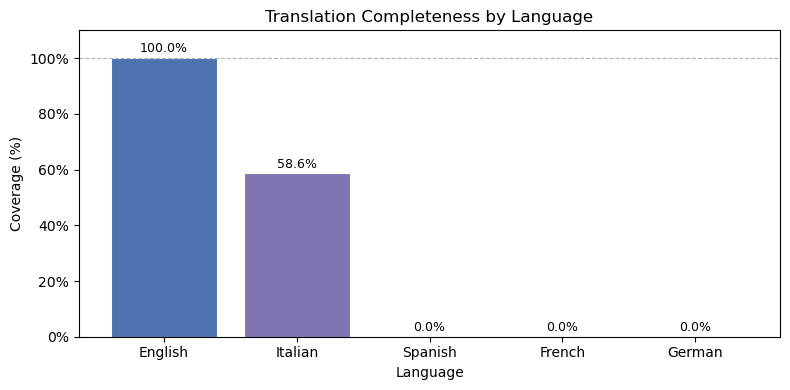

In [22]:
coverage = {}
total = len(trans_df)

for lang in LANGUAGES:
    non_empty = trans_df[lang].notna().sum()
    coverage[lang] = {"count": non_empty, "pct": non_empty / total * 100}

cov_df = pd.DataFrame(coverage).T.sort_values("count", ascending=False)
print("Translation coverage per language:")
display(cov_df.style.format({"count": "{:.0f}", "pct": "{:.1f}%"}))

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(cov_df.index, cov_df["pct"],
              color=[LANG_COLORS[l] for l in cov_df.index], edgecolor="white", linewidth=0.8)
ax.axhline(100, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, 110)
ax.set_xlabel("Language")
ax.set_ylabel("Coverage (%)")
ax.set_title("Translation Completeness by Language")
for bar, pct in zip(bars, cov_df["pct"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

## 7. Sentiment Distribution by Language

For each language, compute counts and percentages of **positive**, **negative**, and **neutral** predictions.

── Sentiment counts per language ──


Sentiment,negative,neutral,positive
Language,,,
English,75,37,88
Spanish,50,28,55
French,83,19,98
German,73,44,83
Italian,85,27,88



── Sentiment % per language ──


Sentiment,negative,neutral,positive
Language,,,
English,37.5000,18.5000,44.0000
Spanish,37.6000,21.1000,41.4000
French,41.5000,9.5000,49.0000
German,36.5000,22.0000,41.5000
Italian,42.5000,13.5000,44.0000


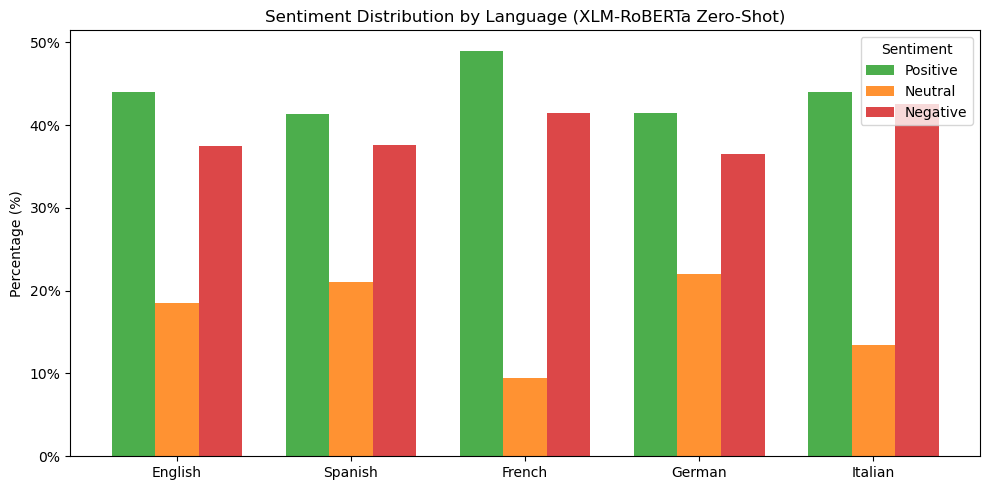

In [23]:
sent_counts = (
    preds.groupby(["Language", "Sentiment"])
    .size()
    .unstack(fill_value=0)
    .reindex(LANGUAGES)
)

sent_pct = sent_counts.div(sent_counts.sum(axis=1), axis=0) * 100

print("── Sentiment counts per language ──")
display(sent_counts)
print("\n── Sentiment % per language ──")
display(sent_pct.round(1))

# Grouped bar chart
sent_order = ["positive", "neutral", "negative"]
x = np.arange(len(LANGUAGES))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
for i, sent in enumerate(sent_order):
    if sent in sent_pct.columns:
        vals = sent_pct.reindex(LANGUAGES)[sent].fillna(0).values
        bars = ax.bar(x + i * width - width, vals, width,
                      label=sent.capitalize(), color=SENT_COLORS[sent], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(LANGUAGES)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylabel("Percentage (%)")
ax.set_title("Sentiment Distribution by Language (XLM-RoBERTa Zero-Shot)")
ax.legend(title="Sentiment")
plt.tight_layout()
plt.show()

## 8. Confidence Score Analysis

Explore how confident the model is, broken down by language and sentiment class.

── Confidence statistics by Language × Sentiment ──


mean  median    std
Language Sentiment                      
English  negative  0.7523  0.7795 0.1482
         neutral   0.5444  0.4998 0.1093
         positive  0.7397  0.7823 0.1318
French   negative  0.7669  0.8015 0.1490
         neutral   0.4850  0.4564 0.1086
         positive  0.7839  0.8373 0.1704
German   negative  0.7261  0.7383 0.1509
         neutral   0.6041  0.5765 0.1246
         positive  0.8035  0.8535 0.1416
Italian  negative  0.7823  0.8093 0.1448
         neutral   0.5594  0.5423 0.1146
         positive  0.7750  0.8129 0.1363
Spanish  negative  0.7599  0.7906 0.1434
         neutral   0.5788  0.5363 0.1326
         positive  0.7703  0.8216 0.1522

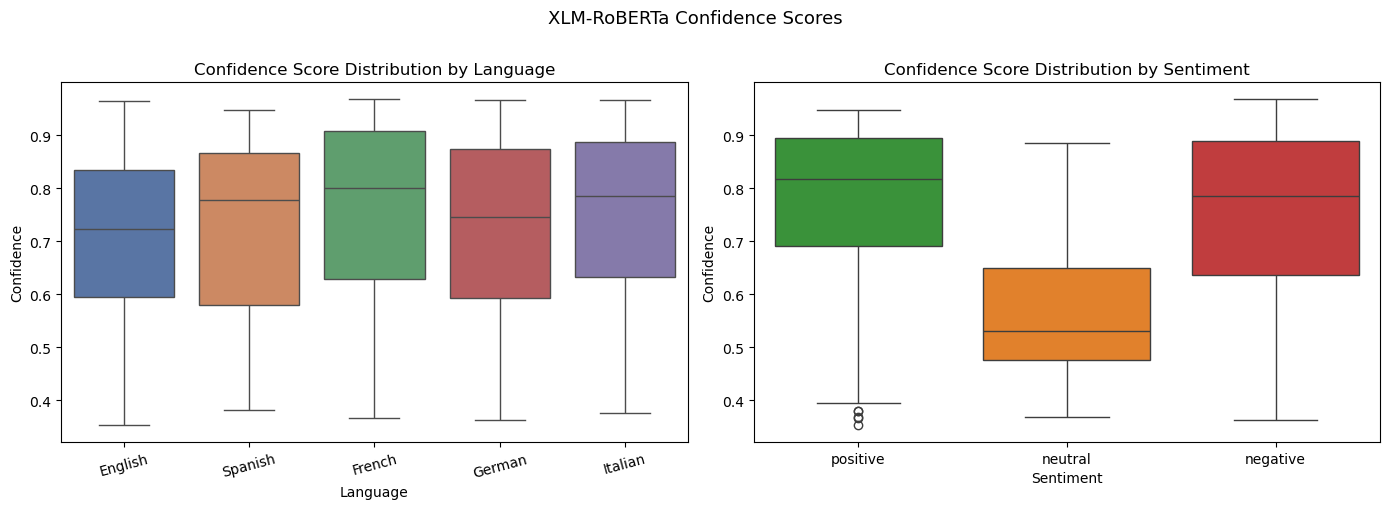

In [24]:
conf_stats = (
    preds.groupby(["Language", "Sentiment"])["Confidence"]
    .agg(["mean", "median", "std"])
    .round(4)
)
print("── Confidence statistics by Language × Sentiment ──")
display(conf_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot by Language
sns.boxplot(data=preds, x="Language", y="Confidence",
            order=LANGUAGES,
            palette=LANG_COLORS, ax=axes[0])
axes[0].set_title("Confidence Score Distribution by Language")
axes[0].set_xlabel("Language")
axes[0].set_ylabel("Confidence")
axes[0].tick_params(axis="x", rotation=15)

# Box plot by Sentiment
sent_palette = {s: SENT_COLORS[s] for s in SENT_COLORS if s in preds["Sentiment"].unique()}
sns.boxplot(data=preds, x="Sentiment", y="Confidence",
            order=["positive", "neutral", "negative"],
            palette=sent_palette, ax=axes[1])
axes[1].set_title("Confidence Score Distribution by Sentiment")
axes[1].set_xlabel("Sentiment")
axes[1].set_ylabel("Confidence")

plt.suptitle("XLM-RoBERTa Confidence Scores", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 9. Missing Translation Detection

Identify sentences where one or more non-English translations are absent.

Missing translation counts per language:


,missing
Spanish,29
French,29
German,29
Italian,12


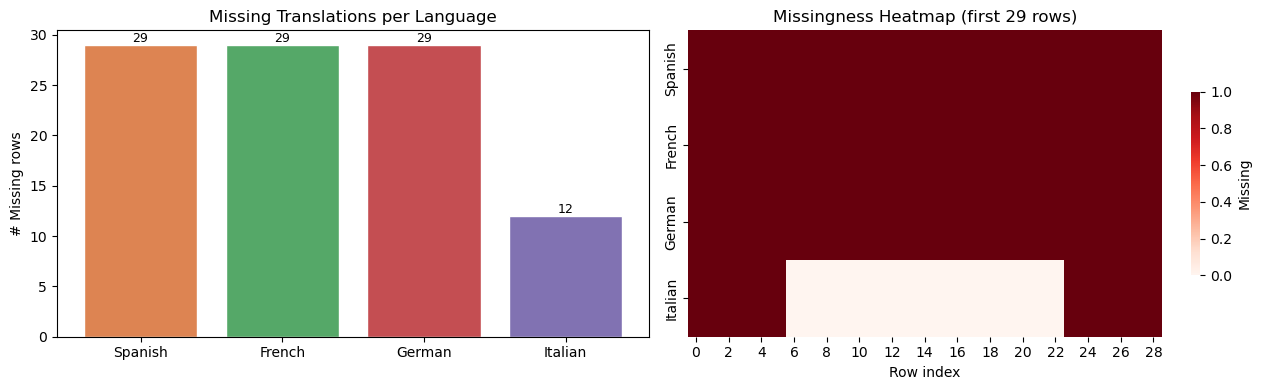

In [25]:
non_eng_langs = [l for l in LANGUAGES if l != "English"]
missing_mask  = trans_df[non_eng_langs].isna()

missing_counts = missing_mask.sum().rename("missing")
print("Missing translation counts per language:")
display(missing_counts.to_frame())

# Boolean matrix for heatmap (sample up to 80 rows for readability)
sample_idx = trans_df.index[:min(80, len(trans_df))]
miss_sample = missing_mask.loc[sample_idx].astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar chart of missing counts
axes[0].bar(missing_counts.index, missing_counts.values,
            color=[LANG_COLORS[l] for l in missing_counts.index], edgecolor="white")
axes[0].set_title("Missing Translations per Language")
axes[0].set_ylabel("# Missing rows")
for i, v in enumerate(missing_counts.values):
    axes[0].text(i, v + 0.3, str(v), ha="center", fontsize=9)

# Missingness heatmap
sns.heatmap(miss_sample.T, cmap="Reds", linewidths=0.0,
            cbar_kws={"shrink": 0.6, "label": "Missing"},
            yticklabels=non_eng_langs, ax=axes[1])
axes[1].set_title(f"Missingness Heatmap (first {len(sample_idx)} rows)")
axes[1].set_xlabel("Row index")

plt.tight_layout()
plt.show()

## 10. Text Length Analysis Across Languages

Compare character lengths and word counts across the five language columns.

── Mean character length per language ──


,char_len,word_count
Language,,
English,76.1000,13.2000
Italian,145.2000,19.5000


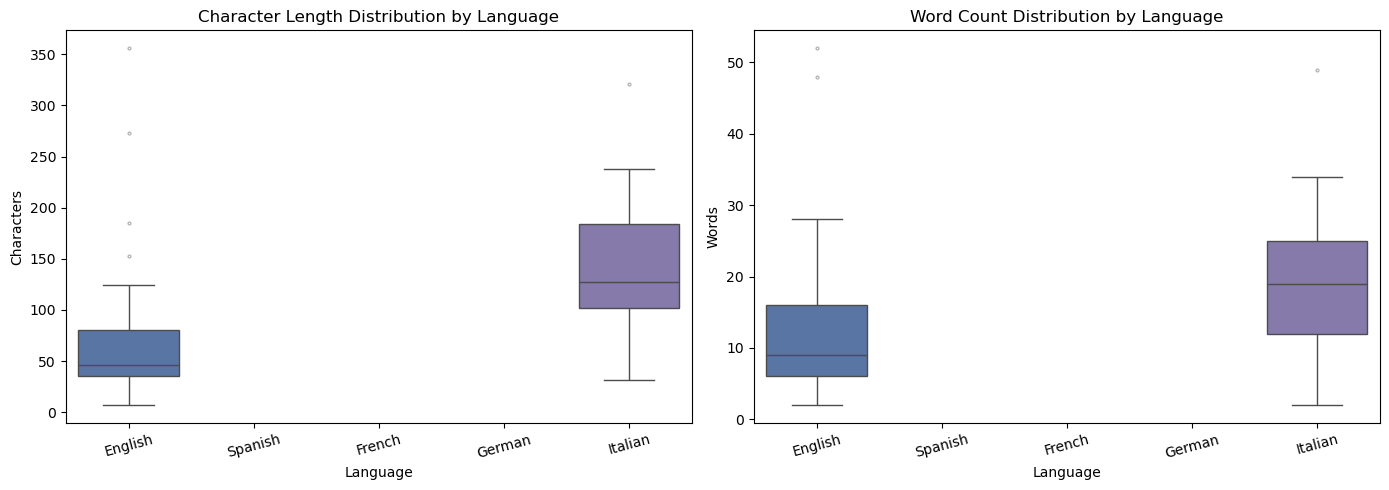

In [26]:
length_data = []
for lang in LANGUAGES:
    col = trans_df[lang].dropna()
    for text in col:
        length_data.append({
            "Language": lang,
            "char_len":  len(str(text)),
            "word_count": len(str(text).split()),
        })

len_df = pd.DataFrame(length_data)

print("── Mean character length per language ──")
display(len_df.groupby("Language")[["char_len", "word_count"]].mean().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Character length
sns.boxplot(data=len_df, x="Language", y="char_len", order=LANGUAGES,
            palette=LANG_COLORS, ax=axes[0], flierprops=dict(markersize=2, alpha=0.4))
axes[0].set_title("Character Length Distribution by Language")
axes[0].set_ylabel("Characters")
axes[0].tick_params(axis="x", rotation=15)

# Word count
sns.boxplot(data=len_df, x="Language", y="word_count", order=LANGUAGES,
            palette=LANG_COLORS, ax=axes[1], flierprops=dict(markersize=2, alpha=0.4))
axes[1].set_title("Word Count Distribution by Language")
axes[1].set_ylabel("Words")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

## 11. Sentiment Distribution Visualization

Overall proportions (pie chart + stacked bar) and the most confidently classified sentences.

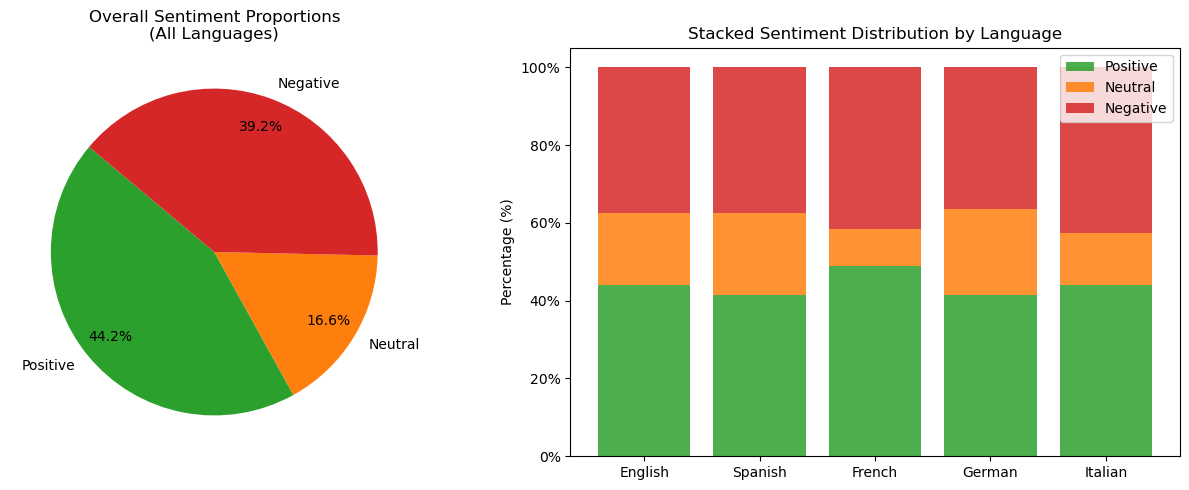


── Top 10 most confident POSITIVE English sentences ──


,Text,Confidence
0,"A wonderful panoramic view at the top and a great way to view the OldCity .,,,,",0.9227
1,"Excellent site to visit and enjoy the view of this superb city by the sea .,,,,",0.9115
2,"A great way to see the surrounding countryside and spectacular views of the OldTown .,,,,",0.9089
3,"A fantastic trip and the view is spectacular .,,,,",0.8992
4,"Although it is expensive it is a great joy to ride it .,,,,",0.8991
5,"A great day out was had by all .,,,,",0.8948
6,"Enjoyable experience .,,,,",0.8920
7,"Fantastic panoramic views of the area and we even had local cattle join us at the top.,,,,",0.8850
8,"Dubrovnik is a beautiful city to walk and explore .,,,,",0.8848
9,"Beautiful views from the top and a cool restaurants which i recommend having a drink at !,,,,",0.8824



── Top 10 most confident NEGATIVE English sentences ──


,Text,Confidence
0,"A complete disgrace to the Croation people .,,,,",0.9654
1,"Extremely disappointed at the way we were treated today .,,,,",0.9508
2,"Drivers are very rude to talk .,,,,",0.9435
3,"Even more disgruntled that we did not even get an apology from the company !,,,,",0.9428
4,"A few passengers looked awful unwell from the long drive and dehydration .,,,,",0.9408
5,"Complete waste of 100kn .,,,,",0.9405
6,"Extremely disappointed with the service .,,,,",0.9401
7,"Expensive and disappointing give it a miss.,,,,",0.9342
8,"A disaster that will not happen again because I will not use your services again .,,,,",0.9331
9,"Because of the huge contrast , I can said that the tour guide of this trip is really bad !,,,,",0.9322


In [27]:
# ── Pie + stacked bar ─────────────────────────────────────────────────────────
overall = preds["Sentiment"].value_counts()
sent_order_all = ["positive", "neutral", "negative"]
overall = overall.reindex(sent_order_all).dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie
wedges, texts, autotexts = axes[0].pie(
    overall.values,
    labels=[s.capitalize() for s in overall.index],
    autopct="%1.1f%%",
    colors=[SENT_COLORS[s] for s in overall.index],
    startangle=140, pctdistance=0.82,
)
axes[0].set_title("Overall Sentiment Proportions\n(All Languages)")

# Stacked bar per language
stacked = sent_pct.reindex(columns=sent_order_all, fill_value=0)
bottom = np.zeros(len(LANGUAGES))
for sent in sent_order_all:
    if sent in stacked.columns:
        axes[1].bar(LANGUAGES, stacked[sent].values,
                    bottom=bottom, label=sent.capitalize(),
                    color=SENT_COLORS[sent], alpha=0.85)
        bottom += stacked[sent].fillna(0).values

axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_ylabel("Percentage (%)")
axes[1].set_title("Stacked Sentiment Distribution by Language")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

# ── Top 10 confident positive / negative (English only) ──────────────────────
print("\n── Top 10 most confident POSITIVE English sentences ──")
display(
    eng_preds[eng_preds["Sentiment"] == "positive"]
    .nlargest(10, "Confidence")[["Text", "Confidence"]]
    .reset_index(drop=True)
)

print("\n── Top 10 most confident NEGATIVE English sentences ──")
display(
    eng_preds[eng_preds["Sentiment"] == "negative"]
    .nlargest(10, "Confidence")[["Text", "Confidence"]]
    .reset_index(drop=True)
)

## 12. High and Low Confidence Sample Inspection

Look at sentences where the model is very certain (> 0.90) vs. uncertain (< 0.45).

In [28]:
high_conf = preds[preds["Confidence"] > 0.90]
low_conf  = preds[preds["Confidence"] < 0.45]

print(f"High-confidence records (> 0.90) : {len(high_conf)}")
print(f"Low-confidence  records (< 0.45) : {len(low_conf)}")

# ── High confidence samples ────────────────────────────────────────────────────
print("\n── Random HIGH-confidence samples (English, by sentiment) ──")
for sent in ["positive", "negative", "neutral"]:
    subset = high_conf[(high_conf["Language"] == "English") & (high_conf["Sentiment"] == sent)]
    n = min(3, len(subset))
    if n:
        print(f"\n  ▸ {sent.upper()} (n={len(subset)})")
        display(subset.sample(n, random_state=42)[["Text", "Confidence"]].reset_index(drop=True))

# ── Low confidence samples ─────────────────────────────────────────────────────
print("\n── Random LOW-confidence samples (English, any sentiment) ──")
low_eng = low_conf[low_conf["Language"] == "English"]
if len(low_eng):
    display(low_eng.sample(min(8, len(low_eng)), random_state=7)[["Text", "Sentiment", "Confidence"]]
            .reset_index(drop=True))

High-confidence records (> 0.90) : 172
Low-confidence  records (< 0.45) : 56

── Random HIGH-confidence samples (English, by sentiment) ──

  ▸ POSITIVE (n=3)


,Text,Confidence
0,"A great way to see the surrounding countryside and spectacular views of the OldTown .,,,,",0.9089
1,"Excellent site to visit and enjoy the view of this superb city by the sea .,,,,",0.9115
2,"A wonderful panoramic view at the top and a great way to view the OldCity .,,,,",0.9227



  ▸ NEGATIVE (n=14)


,Text,Confidence
0,"Extremely disappointed with the service .,,,,",0.9401
1,"Complete waste of 100kn .,,,,",0.9405
2,"Even more disgruntled that we did not even get an apology from the company !,,,,",0.9428



── Random LOW-confidence samples (English, any sentiment) ──


,Text,Sentiment,Confidence
0,"Although always busy the queue shortens quickly .,,,,",neutral,0.4129
1,"Come on , something must be done about this but I am sure as long as people are willing to pay t...",neutral,0.3826
2,"Do not miss the war museum up there .,,,,",positive,0.3520
3,"Do not miss the fort and exhibit , too .,,,,",positive,0.4138
4,"A cable car ride to the top of MountSrd should not be missed when visiting Dubrovnik .,,,,",positive,0.4391
5,"Be sure to climb to the top of the fortress , where you will get a 360 degree view of the area ;...",positive,0.4184
6,"Cant mind price , maybe 10euro or so , worth every penny .,,,,",neutral,0.4266
7,"Both times they have send a standard car without notice me or changed the price .,,,,",negative,0.4358


## 13. Language-wise Sentiment Agreement with English

For each non-English language, measure how often the predicted sentiment matches the English prediction for the same source sentence.

In [29]:
def normalize_key(text):
    """Light normalisation to align texts across language columns."""
    t = str(text).strip().lower()
    t = re.sub(r"[,;]+$", "", t).strip()
    return t

# Build an English lookup: normalised English text → sentiment
eng_lookup = {
    normalize_key(row["Text"]): row["Sentiment"]
    for _, row in preds[preds["Language"] == "English"].iterrows()
}

# For each aligned translation row, look up English sentiment and compare
agreement_rows = []

for _, row in trans_df.iterrows():
    eng_key  = normalize_key(row["English"]) if pd.notna(row["English"]) else None
    eng_sent = eng_lookup.get(eng_key)
    if eng_sent is None:
        continue

    for lang in non_eng_langs:
        trans_text = row[lang]
        if pd.isna(trans_text):
            continue
        # Find the prediction for this translated text
        match = preds[
            (preds["Language"] == lang) &
            (preds["Text"].apply(normalize_key) == normalize_key(trans_text))
        ]
        if match.empty:
            continue
        lang_sent = match.iloc[0]["Sentiment"]
        agreement_rows.append({
            "Language"      : lang,
            "eng_sentiment" : eng_sent,
            "lang_sentiment": lang_sent,
            "agree"         : int(eng_sent == lang_sent),
        })

agree_df = pd.DataFrame(agreement_rows)

if agree_df.empty:
    print("No alignment matches found — check text normalisation.")
else:
    agreement_rate = (
        agree_df.groupby("Language")["agree"]
        .agg(["sum", "count"])
        .assign(agreement_pct=lambda d: d["sum"] / d["count"] * 100)
        .rename(columns={"sum": "matches", "count": "total"})
    )
    print("── Sentiment Agreement Rate with English ──")
    display(agreement_rate.round(2))

    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(agreement_rate.index, agreement_rate["agreement_pct"],
                  color=[LANG_COLORS[l] for l in agreement_rate.index], edgecolor="white")
    ax.axhline(100, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.set_ylim(0, 110)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_ylabel("Agreement with English (%)")
    ax.set_title("XLM-RoBERTa Sentiment Agreement vs. English Baseline")
    for bar, pct in zip(bars, agreement_rate["agreement_pct"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()

    # ── Per-sentiment breakdown ──────────────────────────────────────────────
    print("\n── Agreement rate per Language × English Sentiment ──")
    breakdown = (
        agree_df.groupby(["Language", "eng_sentiment"])["agree"]
        .mean()
        .mul(100)
        .unstack(fill_value=0)
        .round(1)
    )
    display(breakdown)

No alignment matches found — check text normalisation.


---
## Summary

| Aspect | Key findings |
|---|---|
| **Languages** | 5 (EN, ES, FR, DE, IT) across 4 translation blocks |
| **Sentences** | ~200 unique English source sentences (tourism reviews of Dubrovnik cable car & transfers) |
| **Model** | XLM-RoBERTa (zero-shot, 3-class: positive / neutral / negative) |
| **Dominant sentiment** | Negative > Positive > Neutral (reviews include many complaints about transport service) |
| **Confidence** | Negative predictions tend to have higher confidence than neutral ones |
| **Cross-lingual agreement** | Agreement rates between language variants and English can be inspected in Section 13 |

*This notebook can be extended with fine-grained error analysis, topic modelling, or a confusion matrix if ground-truth labels are added.*